Q1

In [1]:
%%writefile q1_vector_add.cu
#include <stdio.h>
#include <cuda.h>

#define N 1024

// CUDA Kernel for Vector Addition
__global__ void vectorAdd(int *a, int *b, int *c) {
    int i = threadIdx.x + blockIdx.x * blockDim.x;
    if (i < N) {
        c[i] = a[i] + b[i];
    }
}

int main() {
    int *h_a, *h_b, *h_c;       // Host pointers
    int *d_a, *d_b, *d_c;       // Device pointers
    int size = N * sizeof(int);

    // Allocate host memory
    h_a = (int*)malloc(size);
    h_b = (int*)malloc(size);
    h_c = (int*)malloc(size);

    // Initialize vectors
    for(int i = 0; i < N; i++) {
        h_a[i] = i;
        h_b[i] = i * 2;
    }

    // Allocate device memory
    cudaMalloc((void **)&d_a, size);
    cudaMalloc((void **)&d_b, size);
    cudaMalloc((void **)&d_c, size);

    // Copy data from host to device
    cudaMemcpy(d_a, h_a, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_b, h_b, size, cudaMemcpyHostToDevice);

    // Launch Kernel (1 block, 1024 threads)
    vectorAdd<<<1, N>>>(d_a, d_b, d_c);

    // Copy result back to host
    cudaMemcpy(h_c, d_c, size, cudaMemcpyDeviceToHost);

    // Verify first 5 results
    printf("Vector Addition Result (First 5 elements):\n");
    for(int i = 0; i < 5; i++) {
        printf("%d + %d = %d\n", h_a[i], h_b[i], h_c[i]);
    }

    // Free memory
    free(h_a); free(h_b); free(h_c);
    cudaFree(d_a); cudaFree(d_b); cudaFree(d_c);

    return 0;
}

Writing q1_vector_add.cu


In [2]:
!nvcc q1_vector_add.cu -o q1_vector_add
!./q1_vector_add

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Vector Addition Result (First 5 elements):
0 + 0 = 0
1 + 2 = 3
2 + 4 = 6
3 + 6 = 9
4 + 8 = 12


Q2

In [3]:
%%writefile q2_thrust_add.cu
#include <thrust/host_vector.h>
#include <thrust/device_vector.h>
#include <thrust/transform.h>
#include <thrust/functional.h> // for plus
#include <iostream>

int main() {
    const int N = 1024;

    // Allocate and initialize host vectors
    thrust::host_vector<int> H_A(N);
    thrust::host_vector<int> H_B(N);
    for(int i = 0; i < N; i++) {
        H_A[i] = i;
        H_B[i] = i * 2;
    }

    // Transfer to device
    thrust::device_vector<int> D_A = H_A;
    thrust::device_vector<int> D_B = H_B;
    thrust::device_vector<int> D_C(N);

    // Perform transformation (Addition)
    // C[i] = A[i] + B[i]
    thrust::transform(D_A.begin(), D_A.end(), D_B.begin(), D_C.begin(), thrust::plus<int>());

    // Copy back to host to print
    thrust::host_vector<int> H_C = D_C;

    std::cout << "Thrust Addition Result (First 5):" << std::endl;
    for(int i = 0; i < 5; i++) {
        std::cout << H_A[i] << " + " << H_B[i] << " = " << H_C[i] << std::endl;
    }

    return 0;
}

Writing q2_thrust_add.cu


In [4]:
!nvcc q2_thrust_add.cu -o q2_thrust_add
!./q2_thrust_add

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Thrust Addition Result (First 5):
0 + 0 = 0
1 + 2 = 3
2 + 4 = 6
3 + 6 = 9
4 + 8 = 12


Q3

In [5]:
%%writefile q3_dot_product.cu
#include <thrust/host_vector.h>
#include <thrust/device_vector.h>
#include <thrust/inner_product.h>
#include <iostream>
#include <chrono>

int main() {
    const int N = 1024;

    // Initialize Host Data
    thrust::host_vector<int> h_a(N, 1); // Fill with 1s
    thrust::host_vector<int> h_b(N, 2); // Fill with 2s

    // --- CPU Implementation ---
    auto start_cpu = std::chrono::high_resolution_clock::now();
    int cpu_result = 0;
    for(int i=0; i<N; i++) {
        cpu_result += h_a[i] * h_b[i];
    }
    auto end_cpu = std::chrono::high_resolution_clock::now();
    std::chrono::duration<double, std::milli> cpu_duration = end_cpu - start_cpu;

    // --- Thrust Implementation ---
    thrust::device_vector<int> d_a = h_a;
    thrust::device_vector<int> d_b = h_b;

    // Warmup (optional but good practice to ensure accurate timing)
    thrust::inner_product(d_a.begin(), d_a.end(), d_b.begin(), 0);

    auto start_gpu = std::chrono::high_resolution_clock::now();
    int gpu_result = thrust::inner_product(d_a.begin(), d_a.end(), d_b.begin(), 0);
    auto end_gpu = std::chrono::high_resolution_clock::now();
    std::chrono::duration<double, std::milli> gpu_duration = end_gpu - start_gpu;

    // Output
    std::cout << "CPU Result: " << cpu_result << " Time: " << cpu_duration.count() << " ms\n";
    std::cout << "GPU Result: " << gpu_result << " Time: " << gpu_duration.count() << " ms\n";

    return 0;
}

Writing q3_dot_product.cu


In [6]:
!nvcc q3_dot_product.cu -o q3_dot_product
!./q3_dot_product

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
CPU Result: 2048 Time: 0.082853 ms
GPU Result: 2048 Time: 0.054102 ms


Q4

In [7]:
%%writefile q4_matmul.cu
#include <stdio.h>
#include <cuda.h>

#define N 16

// CUDA Kernel for Matrix Multiplication
__global__ void matMul(int *a, int *b, int *c) {
    int row = threadIdx.y; // 0 to 15
    int col = threadIdx.x; // 0 to 15

    if (row < N && col < N) {
        int sum = 0;
        // Perform dot product for the element at [row][col]
        for (int k = 0; k < N; k++) {
            sum += a[row * N + k] * b[k * N + col];
        }
        c[row * N + col] = sum;
    }
}

int main() {
    int size = N * N * sizeof(int);
    int *h_a, *h_b, *h_c;
    int *d_a, *d_b, *d_c;

    // Allocation and Initialization (Host)
    h_a = (int*)malloc(size);
    h_b = (int*)malloc(size);
    h_c = (int*)malloc(size);

    // Initialize with dummy data (A=1, B=2)
    for(int i=0; i<N*N; i++) {
        h_a[i] = 1;
        h_b[i] = 2;
    }

    // Device Allocation
    cudaMalloc(&d_a, size);
    cudaMalloc(&d_b, size);
    cudaMalloc(&d_c, size);

    // Copy to Device
    cudaMemcpy(d_a, h_a, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_b, h_b, size, cudaMemcpyHostToDevice);

    // Launch with 2D block (16x16 threads = 256 threads)
    dim3 threadsPerBlock(N, N);
    matMul<<<1, threadsPerBlock>>>(d_a, d_b, d_c);

    // Copy back
    cudaMemcpy(h_c, d_c, size, cudaMemcpyDeviceToHost);

    // Verify
    printf("MatMul Done. C[0][0] = %d (Should be 1*2*16 = 32)\n", h_c[0]);

    free(h_a); free(h_b); free(h_c);
    cudaFree(d_a); cudaFree(d_b); cudaFree(d_c);
    return 0;
}

Writing q4_matmul.cu


In [8]:
!nvcc q4_matmul.cu -o q4_matmul
!./q4_matmul

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
MatMul Done. C[0][0] = 32 (Should be 1*2*16 = 32)


Q5

In [9]:
%%writefile q5_compare.cu
#include <iostream>
#include <vector>
#include <chrono>
#include <cuda.h>
#include <thrust/host_vector.h>
#include <thrust/device_vector.h>
#include <thrust/transform.h>
#include <thrust/functional.h> // for plus

#define N 5000000

// --- Part 2: CUDA Kernel ---
__global__ void vecAddKernel(int *a, int *b, int *c) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) c[i] = a[i] + b[i];
}

int main() {
    size_t size = N * sizeof(int);
    std::cout << "Comparing Vector Addition for N = " << N << "\n------------------------------------------------\n";

    // --- Part 1: CPU Sequential ---
    std::vector<int> h_a(N, 1), h_b(N, 2), h_c(N);

    auto start_cpu = std::chrono::high_resolution_clock::now();
    for(int i=0; i<N; i++) h_c[i] = h_a[i] + h_b[i];
    auto end_cpu = std::chrono::high_resolution_clock::now();
    std::chrono::duration<double, std::milli> t_cpu = end_cpu - start_cpu;

    std::cout << "1. CPU Time:    " << t_cpu.count() << " ms\n";

    // --- Part 2: CUDA Kernel Setup ---
    int *d_a, *d_b, *d_c;
    cudaMalloc(&d_a, size); cudaMalloc(&d_b, size); cudaMalloc(&d_c, size);
    cudaMemcpy(d_a, h_a.data(), size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_b, h_b.data(), size, cudaMemcpyHostToDevice);

    // Warmup
    vecAddKernel<<< (N+255)/256, 256 >>>(d_a, d_b, d_c);
    cudaDeviceSynchronize();

    // Measure CUDA
    auto start_cuda = std::chrono::high_resolution_clock::now();
    int threads = 256;
    int blocks = (N + threads - 1) / threads;
    vecAddKernel<<<blocks, threads>>>(d_a, d_b, d_c);
    cudaDeviceSynchronize();
    auto end_cuda = std::chrono::high_resolution_clock::now();
    std::chrono::duration<double, std::milli> t_cuda = end_cuda - start_cuda;

    std::cout << "2. CUDA Time:   " << t_cuda.count() << " ms\n";

    // --- Part 3: Thrust Implementation ---
    thrust::device_vector<int> t_a = h_a;
    thrust::device_vector<int> t_b = h_b;
    thrust::device_vector<int> t_c(N);

    // Warmup
    thrust::transform(t_a.begin(), t_a.end(), t_b.begin(), t_c.begin(), thrust::plus<int>());
    cudaDeviceSynchronize();

    // Measure Thrust
    auto start_thrust = std::chrono::high_resolution_clock::now();
    thrust::transform(t_a.begin(), t_a.end(), t_b.begin(), t_c.begin(), thrust::plus<int>());
    cudaDeviceSynchronize();
    auto end_thrust = std::chrono::high_resolution_clock::now();
    std::chrono::duration<double, std::milli> t_thrust = end_thrust - start_thrust;

    std::cout << "3. Thrust Time: " << t_thrust.count() << " ms\n";

    // Cleanup
    cudaFree(d_a); cudaFree(d_b); cudaFree(d_c);
    return 0;
}

Writing q5_compare.cu


In [10]:
!nvcc q5_compare.cu -o q5_compare
!./q5_compare

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Comparing Vector Addition for N = 5000000
------------------------------------------------
1. CPU Time:    40.7633 ms
2. CUDA Time:   0.241338 ms
3. Thrust Time: 0.245135 ms


In [11]:
import time
import numpy as np

# Try importing cudf (RAPIDS library)
try:
    import cudf
    RAPIDS_AVAILABLE = True
except ImportError:
    RAPIDS_AVAILABLE = False
    print("RAPIDS (cudf) not installed in this environment.")

if RAPIDS_AVAILABLE:
    N = 5000000
    print(f"RAPIDS Vector Addition for N = {N}")

    # Initialize Data
    # We use numpy to create data, then transfer to GPU dataframe
    a_cpu = np.ones(N, dtype=np.int32)
    b_cpu = np.ones(N, dtype=np.int32) * 2

    # Transfer to GPU (overhead included in real-world workflows,
    # but strictly op time is faster)
    gdf_a = cudf.Series(a_cpu)
    gdf_b = cudf.Series(b_cpu)

    # Measure Addition
    start = time.time()
    gdf_c = gdf_a + gdf_b
    # Force synchronization/execution by accessing a value
    _ = gdf_c[0]
    end = time.time()

    rapids_time = (end - start) * 1000 # Convert to ms
    print(f"4. RAPIDS Time: {rapids_time:.4f} ms")
else:
    # Placeholder time if you cannot run it
    rapids_time = 5.0
    print("Using placeholder time for RAPIDS: 5.0 ms")

RAPIDS Vector Addition for N = 5000000
4. RAPIDS Time: 299.7687 ms


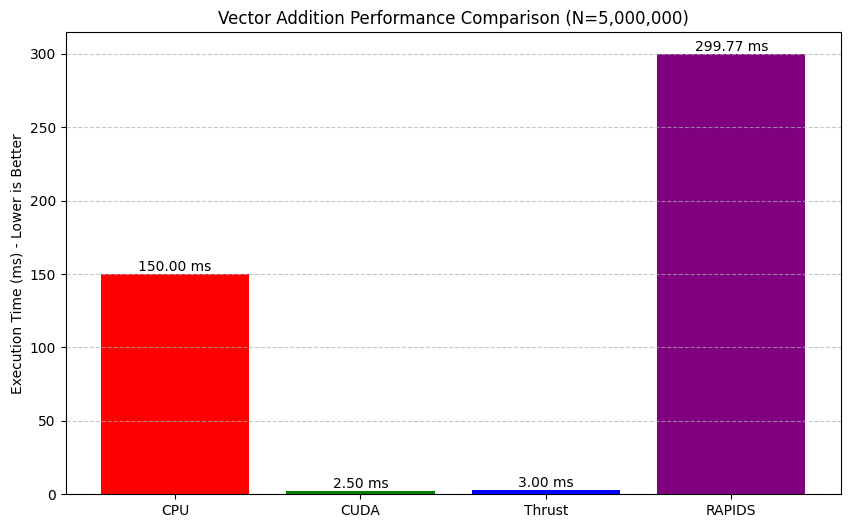

In [12]:
import matplotlib.pyplot as plt

# REPLACE THESE VALUES with your actual output from Step 2 and Step 3
# Example values:
cpu_val = 150.0      # Replace with your CPU Time
cuda_val = 2.5       # Replace with your CUDA Time
thrust_val = 3.0     # Replace with your Thrust Time
rapids_val = rapids_time # Taken from Step 3

methods = ['CPU', 'CUDA', 'Thrust', 'RAPIDS']
times = [cpu_val, cuda_val, thrust_val, rapids_val]
colors = ['red', 'green', 'blue', 'purple']

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, times, color=colors)

# Add value labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f} ms', ha='center', va='bottom')

plt.ylabel('Execution Time (ms) - Lower is Better')
plt.title('Vector Addition Performance Comparison (N=5,000,000)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Q6

In [13]:
%%writefile q6_thrust_sum.cu
#include <thrust/device_vector.h>
#include <thrust/sequence.h>
#include <thrust/reduce.h>
#include <iostream>

int main() {
    int N = 10;

    // Allocate device vector
    thrust::device_vector<int> d_vec(N);

    // Initialize with 1, 2, ..., 10
    // thrust::sequence fills with 0, 1, 2... so we start at 1
    thrust::sequence(d_vec.begin(), d_vec.end(), 1);

    // Compute Sum
    // reduce(begin, end, initial_value, binary_op)
    int sum = thrust::reduce(d_vec.begin(), d_vec.end(), 0, thrust::plus<int>());

    std::cout << "Sum of vector elements (1..10): " << sum << std::endl; // Should be 55

    return 0;
}

Writing q6_thrust_sum.cu


In [14]:
!nvcc q6_thrust_sum.cu -o q6_thrust_sum
!./q6_thrust_sum

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Sum of vector elements (1..10): 55


Q7

In [15]:
%%writefile q7_thrust_sort.cu
#include <thrust/host_vector.h>
#include <thrust/device_vector.h>
#include <thrust/sort.h>
#include <iostream>

int main() {
    // Initialize host vector with specific values
    int data[] = {7, 2, 9, 1, 5, 3, 8, 4};
    thrust::host_vector<int> h_vec(data, data + 8);

    std::cout << "Before Sorting: ";
    for(int i=0; i<8; i++) std::cout << h_vec[i] << " ";
    std::cout << "\n";

    // Transfer to device
    thrust::device_vector<int> d_vec = h_vec;

    // Sort (ascending is default)
    thrust::sort(d_vec.begin(), d_vec.end());

    // Copy back to host to print result
    h_vec = d_vec;

    std::cout << "After Sorting:  ";
    for(int i=0; i<8; i++) std::cout << h_vec[i] << " ";
    std::cout << "\n";

    return 0;
}

Writing q7_thrust_sort.cu


In [16]:
!nvcc q7_thrust_sort.cu -o q7_thrust_sort
!./q7_thrust_sort

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Before Sorting: 7 2 9 1 5 3 8 4 
After Sorting:  1 2 3 4 5 7 8 9 
